# 统计与大数据分析 · 第一次作业

## 图 1：标准正态分布的概率密度曲线

In [10]:
# 导入所需的包：matplotlib.pyplot 负责绘图，numpy 负责数值计算
import numpy as np
import matplotlib.pyplot as plt

# 让图中的中文能够正常显示。这里按顺序尝试几种常见中文字体，
# 找不到时会自动回退到后面的字体。
plt.rcParams["font.sans-serif"] = [
    "Microsoft YaHei",
    "SimHei",
    "PingFang SC",
    "Noto Sans CJK SC",
    "DejaVu Sans",
]
plt.rcParams["axes.unicode_minus"] = False  # 保证负号正常显示

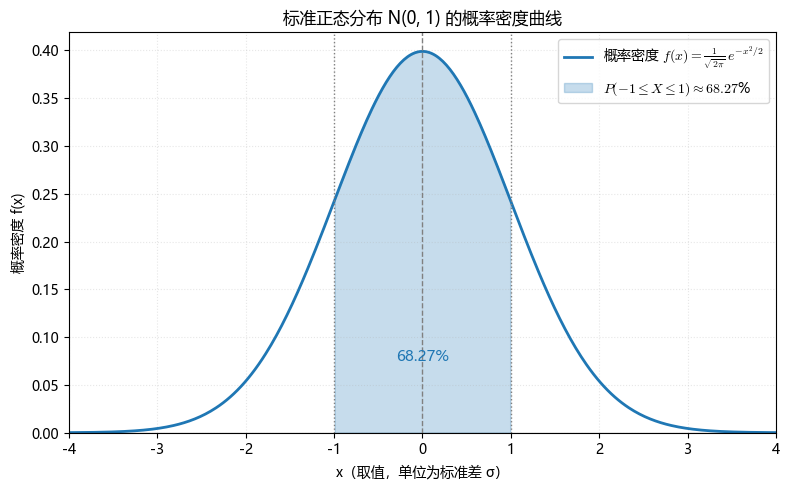

In [11]:
x = np.linspace(-4, 4, 400)
y = np.exp(-(x**2) / 2) / np.sqrt(2 * np.pi)  # f(x) = exp(-x^2/2) / sqrt(2*pi)

fig, ax = plt.subplots(figsize=(8, 5))

ax.plot(
    x,
    y,
    color="#1f77b4",
    linewidth=2,
    label=r"概率密度 $f(x)=\frac{1}{\sqrt{2\pi}}\,e^{-x^2/2}$",
)

mask = (x >= -1) & (x <= 1)
ax.fill_between(
    x[mask],
    y[mask],
    color="#1f77b4",
    alpha=0.25,
    label=r"$P(-1 \leq X \leq 1) \approx 68.27$%",
)

ax.set_xlabel("x（取值，单位为标准差 σ）")
ax.set_ylabel("概率密度 f(x)")
ax.set_title("标准正态分布 N(0, 1) 的概率密度曲线")
ax.set_xticks(np.arange(-4, 5, 1))
ax.set_xlim(-4, 4)
ax.set_ylim(bottom=0)
ax.axhline(0, color="black", linewidth=0.8)  # x 轴
ax.axvline(0, color="gray", linewidth=1, linestyle="--")  # 对称轴 x = 0
for x0 in (-1, 1):  # ±1 分界线
    ax.axvline(x0, color="gray", linewidth=1, linestyle=":")
ax.grid(alpha=0.3, linestyle=":")
ax.annotate("68.27%", xy=(0, 0.075), ha="center", fontsize=11, color="#1f77b4")
ax.legend(loc="upper right")

fig.tight_layout()
plt.show()

### 图 1 的内容解释

- **x 轴**：随机变量 $X$ 的取值，也就是"偏离均值 0 多少个标准差"，即通常所说的 z 值（z-score）。刻度取 $-4$ 到 $4$ 的整数，已经覆盖了几乎全部的概率。
- **y 轴**：概率密度 $f(x)$，即曲线在 $x$ 处的纵坐标。概率密度不是概率，**曲线下方的面积才是概率**，整条曲线与 x 轴围成的总面积等于 $1$。
- **蓝色曲线**：标准正态分布 $N(0,1)$ 的概率密度函数
  $$f(x)=\frac{1}{\sqrt{2\pi}}\,e^{-x^{2}/2},$$
  它关于 $x=0$ 对称，在 $x=0$ 处取到最大值 $f(0)=1/\sqrt{2\pi}\approx 0.399$，向两侧迅速衰减，形状像一口钟。
- **阴影区域**：$-1 \le x \le 1$ 之间的面积，表示 $X$ 落在"均值 ± 一个标准差"以内的概率，约为 $68.27\%$。同理，$\pm 2\sigma$ 内的概率约为 $95.45\%$，$\pm 3\sigma$ 内约为 $99.73\%$，这就是常说的 **68–95–99.7 法则**。
- **虚线**：$x=0$ 是对称轴，也是概率密度的最大值点；$x=\pm 1$ 是阴影区域的左右边界。

从这张图可以看出：正态分布的取值大部分集中在均值附近，极端值很少出现。这正是一般的测量误差、身高、考试成绩等大量随机现象都可以用正态分布来刻画的原因。

## 图 2（补充）：大样本直方图与理论密度曲线的对比

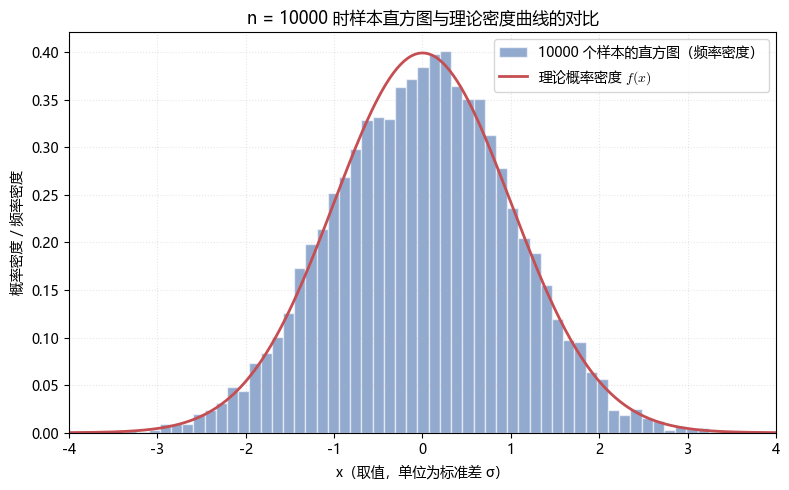

In [12]:
rng = np.random.default_rng(2026)
samples = rng.normal(loc=0.0, scale=1.0, size=10000)

fig, ax = plt.subplots(figsize=(8, 5))
ax.hist(
    samples,
    bins=60,
    density=True,
    color="#4c72b0",
    alpha=0.6,
    edgecolor="white",
    label="10000 个样本的直方图（频率密度）",
)
ax.plot(x, y, color="#c44e52", linewidth=2, label=r"理论概率密度 $f(x)$")
ax.set_xlabel("x（取值，单位为标准差 σ）")
ax.set_ylabel("概率密度 / 频率密度")
ax.set_title("n = 10000 时样本直方图与理论密度曲线的对比")
ax.set_xlim(-4, 4)
ax.grid(alpha=0.3, linestyle=":")
ax.legend(loc="upper right")

fig.tight_layout()
plt.show()

### 图 2 的内容解释

- **x 轴 / y 轴**：含义与图 1 相同，分别是样本的取值和（频率）密度。直方图使用 `density=True`，使所有柱子的总面积等于 $1$，这样才能与概率密度曲线直接比较。
- **蓝色柱形**：由 `numpy.random` 生成的 10000 个 $N(0,1)$ 样本落在 60 个小区间内的频率密度。样本量越大、区间越细，柱顶轮廓就越光滑。
- **红色曲线**：与图 1 完全相同的理论概率密度 $f(x)$。
- **结论**：随着样本量 $n$ 增大，样本直方图会逐渐逼近总体的概率密度曲线。这正是用样本推断总体分布的依据，也是数据分析中最基本的"大样本"思想。

## 图 3 ：用三次贝塞尔曲线绘制奶龙

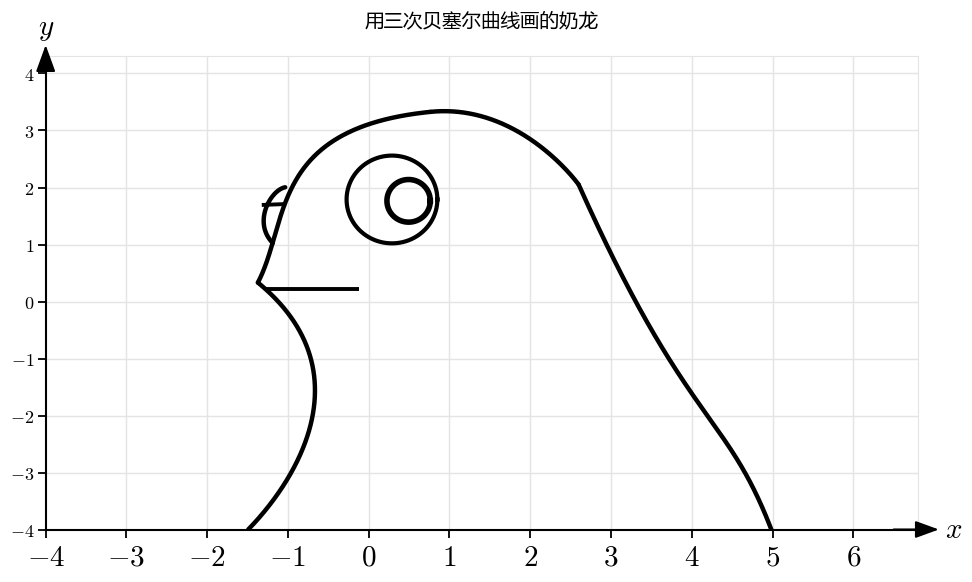

In [13]:
plt.rcParams["mathtext.fontset"] = "cm"


def bezier(P, t):
    P = np.asarray(P, float)
    t = np.asarray(t, float)[:, None]
    return (
        (1 - t) ** 3 * P[0]
        + 3 * (1 - t) ** 2 * t * P[1]
        + 3 * (1 - t) * t**2 * P[2]
        + t**3 * P[3]
    )


s = np.linspace(0.0, 1.0, 800)  # 参数 t 的离散取值
theta = np.linspace(0.0, 2 * np.pi, 800)  # 画椭圆用的参数

r1 = [
    (-1.492, -4.000),
    (-0.824, -3.029),
    (-0.084, -1.161),
    (-1.372, 0.332),
]
r2 = [
    (-1.372, 0.332),
    (-0.980, 1.397),
    (-1.228, 3.044),
    (0.765, 3.327),
]
r3 = [
    (0.765, 3.327),
    (1.872, 3.485),
    (2.597, 2.058),
    (2.600, 2.050),
]
r4 = [
    (2.600, 2.050),
    (3.931, -2.165),
    (4.427, -1.932),
    (4.985, -4.000),
]
r5 = [
    (-1.188, 1.026),
    (-1.443, 1.393),
    (-1.210, 1.961),
    (-1.034, 2.004),
]

eye_c, eye_a, eye_b = (0.288, 1.790), 0.562, 0.770
pup_c, pup_a, pup_b = (0.494, 1.766), 0.2685, 0.374
mouth = np.array([[-1.281, 0.2215], [-0.117, 0.2215]])
fold = np.array([[-1.300, 1.695], [-1.062, 1.708]])

PX_X, PX_Y = 121.1, 85.5
XLIM, YLIM = (-4.0, 6.8), (-4.0, 4.31)
fig = plt.figure(figsize=(10.03, 5.90))
ax = fig.add_axes(
    [
        106.7 / 1504,
        115.0 / 885,
        (XLIM[1] - XLIM[0]) * PX_X / 1504,
        (YLIM[1] - YLIM[0]) * PX_Y / 885,
    ]
)
ax.set_xlim(*XLIM)
ax.set_ylim(*YLIM)

GRID = "#e4e4e4"
for side in ("top", "right"):
    ax.spines[side].set_color(GRID)
ax.spines["bottom"].set_linewidth(1.5)
ax.spines["left"].set_linewidth(1.5)
ax.set_xticks(range(-4, 7))
ax.set_yticks(range(-4, 5))
ax.set_xticklabels([f"${v}$" for v in range(-4, 7)], fontsize=21)
ax.set_yticklabels([f"${v}$" for v in range(-4, 5)], fontsize=13)
ax.tick_params(axis="x", length=6, width=1.3, pad=3)
ax.tick_params(axis="y", length=6, width=1.3, pad=2)
for gx in range(-3, 7):
    ax.plot([gx, gx], [YLIM[0], YLIM[1]], color=GRID, lw=1.0, zorder=0)
for gy in range(-3, 5):
    ax.plot([XLIM[0], XLIM[1]], [gy, gy], color=GRID, lw=1.0, zorder=0)
ARROW = dict(
    arrowstyle="-|>,head_length=1.1,head_width=0.40",
    color="black",
    lw=1.5,
    shrinkA=0,
    shrinkB=0,
)
ax.annotate(
    "",
    xy=(7.06, -4),
    xytext=(6.5, -4),
    annotation_clip=False,
    arrowprops=dict(ARROW, mutation_scale=13),
)
ax.annotate(
    "",
    xy=(-4, 4.50),
    xytext=(-4, 4.06),
    annotation_clip=False,
    arrowprops=dict(ARROW, mutation_scale=15),
)
ax.text(7.14, -4, "$x$", fontsize=21, ha="left", va="center", clip_on=False)
ax.text(-4.0, 4.55, "$y$", fontsize=21, ha="center", va="bottom", clip_on=False)

for P in (r1, r2, r3, r4, r5):
    C = bezier(P, s)
    ax.plot(C[:, 0], C[:, 1], color="black", lw=3.2, solid_capstyle="round", zorder=4)
ax.plot(fold[:, 0], fold[:, 1], color="black", lw=2.8, zorder=4)  # 呆毛的折线
ax.plot(
    mouth[:, 0], mouth[:, 1], color="black", lw=2.8, zorder=4, solid_capstyle="butt"
)
ax.plot(
    eye_c[0] + eye_a * np.cos(theta),
    eye_c[1] + eye_b * np.sin(theta),
    color="black",
    lw=3.0,
    zorder=4,
)
ax.plot(
    pup_c[0] + pup_a * np.cos(theta),
    pup_c[1] + pup_b * np.sin(theta),
    color="black",
    lw=4.0,
    zorder=4,
)

ax.set_title("用三次贝塞尔曲线画的奶龙", fontsize=14, pad=22)
plt.show()